# Supervised Fine-Tuning (SFT) dengan LoRA
## Studi Kasus: Bahasa Daerah Indonesia

**Tujuan:** Fine-tune small language model agar dapat mengikuti instruksi dalam bahasa daerah Indonesia.

**Stack:**
- `transformers` — load model & tokenizer
- `peft` — LoRA implementation
- `trl` — SFTTrainer
- `datasets` — load & process data

> ⚠️ Tidak menggunakan Unsloth atau layanan as-a-service. Semua dibangun dari library standar HuggingFace.

## Resources

**Eksperimen oleh:**
- Nama: Bruri Wijayanto
- NIM : 25/568904/PPA/07156

**Environment:**
- Google Colab
- Python 3
- GPU Tesla T4


## 0. Instalasi Dependencies

In [4]:
# Jalankan sekali saja di awal
# Di Colab: hapus tanda '#' di bawah
!pip install -q transformers==4.44.0 peft==0.12.0 trl==0.10.1 datasets accelerate bitsandbytes

## 1. Import dan Konfigurasi

In [5]:
import os
import json
import torch
from dataclasses import dataclass, field
from typing import List, Dict, Optional

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
)
from peft import LoraConfig, TaskType, get_peft_model, PeftModel
from trl import SFTTrainer, SFTConfig, DataCollatorForCompletionOnlyLM

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4
VRAM            : 15.6 GB


## 2. Konfigurasi Global

Ubah nilai di bawah sesuai pilihan Anda. Tidak perlu menyentuh kode lain.

In [6]:
# ============================================================
#   KONFIGURASI — ubah sesuai kebutuhan
# ============================================================

# --- Pilihan model (uncomment satu) ---
# MODEL_ID = "HuggingFaceTB/SmolLM2-360M"          # ~360M param, sangat cepat
MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"  # ~1.1B param
# MODEL_ID = "Qwen/Qwen2.5-0.5B"                   # ~0.5B param, performa bagus
# MODEL_ID = "google/gemma-2-2b"                   # ~2B param, butuh akses HF
# MODEL_ID = "microsoft/Phi-3-mini-4k-instruct"    # ~3.8B param, pakai 4-bit

# --- Pilihan dataset ---
DATASET_CHOICE = "synthetic"   # 'synthetic' | 'nusax' | 'cendol' | 'bryandts'

# --- Direktori output ---
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# --- Direktori output → arahkan ke Google Drive ---
BASE_DRIVE   = "/content/drive/MyDrive/SFT_LoRA_Tugas"
OUTPUT_DIR   = f"{BASE_DRIVE}/output/sft-lora"
ADAPTER_DIR  = f"{BASE_DRIVE}/output/adapter"
MERGED_DIR   = f"{BASE_DRIVE}/output/merged-model"

# Buat folder jika belum ada
import os
os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(ADAPTER_DIR, exist_ok=True)
os.makedirs(MERGED_DIR,  exist_ok=True)

print("✅ Output akan disimpan ke Google Drive:")
print(f"   {BASE_DRIVE}")

# --- Hyperparameter pelatihan ---
MAX_SEQ_LEN     = 512
NUM_EPOCHS      = 10   # dari 2
BATCH_SIZE      = 1    # dari 2
GRAD_ACCUM      = 2    # dari 4
LEARNING_RATE   = 2e-4
MAX_TRAIN_SAMPLES = 1000  # None = pakai semua

# --- LoRA hyperparameter ---
LORA_R      = 16   # dari 8
LORA_ALPHA  = 32   # dari 16
LORA_DROPOUT = 0.05

# --- Kuantisasi (aktifkan untuk model >=2B di GPU < 8GB) ---
USE_4BIT = False

# Seed untuk reproducibility
SEED = 42
torch.manual_seed(SEED)

Mounted at /content/drive
✅ Output akan disimpan ke Google Drive:
   /content/drive/MyDrive/SFT_LoRA_Tugas


## 3. Bagian Eksplorasi: Mengapa Base Model Lemah dalam Mengikuti Instruksi?

> **Pertanyaan kunci:** Model yang dilatih pada triliunan token teks internet memiliki pengetahuan luas, tapi mengapa gagal menjawab instruksi sederhana?

In [7]:
# Muat tokenizer dan base model terlebih dahulu
print(f"Memuat model: {MODEL_ID}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)

# Pastikan tokenizer punya pad token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print(f"Vocabulary size : {tokenizer.vocab_size:,}")
print(f"EOS token       : {tokenizer.eos_token!r}")
print(f"PAD token       : {tokenizer.pad_token!r}")

Memuat model: TinyLlama/TinyLlama-1.1B-Chat-v1.0


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

Vocabulary size : 32,000
EOS token       : '</s>'
PAD token       : '</s>'


In [8]:
# Konfigurasi kuantisasi (opsional)
bnb_config = None
if USE_4BIT:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
    )

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
    trust_remote_code=True,
)

total_params  = sum(p.numel() for p in base_model.parameters())
print(f"Total parameter : {total_params:,} ({total_params/1e6:.1f}M)")

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Total parameter : 1,100,048,384 (1100.0M)


In [9]:
def generate_text(model, tokenizer, prompt: str, max_new_tokens: int = 200) -> str:
    """Generate teks dengan chat template.

    TinyLlama-Chat WAJIB menerima prompt dalam format:
        <|system|>...<|user|>instruksi</s><|assistant|>
    Tanpa format ini, model tidak tahu harus menjawab → output acak.
    """
    model.eval()
    device = next(model.parameters()).device

    # Bungkus prompt dengan chat template
    messages = [{"role": "user", "content": prompt}]
    try:
        # add_generation_prompt=True → tambah <|assistant|> di akhir
        # sinyal ke model: "sekarang giliranmu menjawab"
        formatted = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )
    except Exception:
        formatted = f"### Instruksi:\n{prompt}\n\n### Respons:\n"

    inputs = tokenizer(formatted, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    # Ambil HANYA token yang digenerate (bukan bagian prompt)
    generated = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True).strip()


# ── Test langsung setelah ganti ─────────────────────────────
# (jalankan setelah base_model sudah dimuat di sel sebelumnya)
print("=" * 65)
print("  RESPONS BASE MODEL (sebelum fine-tuning)")
print("=" * 65)

test_prompts = [
    "Apa makna filosofi Jawa 'Memayu Hayuning Bawana'?",
    "Bagaimana cara membuat gudeg? Jelaskan langkah-langkahnya.",
    "Ceritakan legenda Sangkuriang dari Jawa Barat.",
]

base_responses_store = {}
for prompt in test_prompts:
    print(f"\n📌 INSTRUKSI : {prompt}")
    resp = generate_text(base_model, tokenizer, prompt, max_new_tokens=150)
    base_responses_store[prompt] = resp
    print(f"🤖 RESPONS   : {resp[:350]}")
    print("-" * 65)

print("""
📝 ANALISIS:
TinyLlama-1.1B-Chat sudah bisa merespons instruksi karena punya chat
template bawaan. Namun jawaban tentang budaya Nusantara masih generik
dan sering berbahasa Inggris — karena pre-training didominasi teks Inggris.
Setelah SFT pada dataset bahasa daerah, kita harapkan:
  ✓ Jawaban dalam bahasa Indonesia
  ✓ Konten relevan dengan budaya Nusantara
  ✓ Format terstruktur sesuai instruksi
""")

  RESPONS BASE MODEL (sebelum fine-tuning)

📌 INSTRUKSI : Apa makna filosofi Jawa 'Memayu Hayuning Bawana'?
🤖 RESPONS   : Filosofi Jawa 'Memayu Hayuning Bawana' (Javanese: Memuyuh Hayuning Bawaan; literally "The Path of Harmonious Concordance") is a philosophy developed by the Javanese philosopher and poet Purnama Taheruddin. The term "Hayuning" refers to the concept of balance, harmony, and unity in all aspects of life, while "Bawaan" emphasizes the importance of liv
-----------------------------------------------------------------

📌 INSTRUKSI : Bagaimana cara membuat gudeg? Jelaskan langkah-langkahnya.
🤖 RESPONS   : Membuat gudeg (bakso kacang) adalah proses pengolahan makanan yang berasal dari kucing dan memiliki sambal, saladang, atau nasi bumi yang menjadi salah satu objek makanan yang sangat populer di Indonesia. Oleh karena itu, jika ingin membuat gudeg, Anda harus mempercantikkan makanan dengan menggunakan alat-alat yang sudah disediakan oleh orang tua a
----------------------

## 4. Persiapan Dataset

### Pilihan Dataset Bahasa Daerah Indonesia

| Dataset | HuggingFace ID | Bahasa | Format |
|---------|---------------|--------|--------|
| **Cendol Collection v2** | `indonlp/cendol_collection_v2` | 10+ regional (Jawa, Sunda, Batak, Bugis...) | instruction-output |
| **Bryandts Instruct** | `bryandts/instruction-dataset-indo-java-sunda-bali-gayo-batak-alas-minang-betawi` | 9 bahasa daerah | instruction-input-output |
| **NusaX-MT** | `indonlp/NusaX-MT` | 12 bahasa (ID + 10 regional) | parallel translation |
| **NusaX-Senti** | `SEACrowd/nusax_senti` | 12 bahasa | sentiment classification |
| **Javanese Stories** | `Iftitahu/javanese_instruct_stories` | Jawa-Indonesia-Inggris | translation instruction |
| **IndoNLG** | `GEM/indonlg` | ID, Jawa, Sunda | QA, summarization, MT, dialog |
| **Korpus Nusantara** | `SEACrowd/korpus_nusantara` | 25 dialek | parallel translation |
| **Cendol v1** | `indonlp/cendol_collection_v1` | 10+ regional | task-specific instruction |

> **Rekomendasi:** Gunakan `bryandts/...` atau `indonlp/cendol_collection_v2` untuk SFT langsung karena sudah dalam format instruksi.

In [10]:
# ============================================================
#   DATASET SINTETIS BAHASA DAERAH (built-in, tanpa download)
#   Gunakan ini jika tidak ada koneksi internet
# ============================================================

SYNTHETIC_DATA = [
    # ── ADAT & TRADISI JAWA ─────────────────────────────────
    {
        "instruction": "Apa makna filosofi Jawa 'Memayu Hayuning Bawana'?",
        "input": "",
        "output": "Memayu Hayuning Bawana adalah filosofi Jawa yang berarti 'memperindah keindahan dunia'. Filosofi ini mengajarkan bahwa setiap manusia memiliki tanggung jawab untuk menjaga keselarasan, keharmonisan, dan keindahan alam semesta. Manusia tidak hanya hidup untuk dirinya sendiri, tetapi juga untuk merawat bumi dan sesama makhluk hidup. Dalam praktiknya, filosofi ini mendorong perilaku gotong royong, menjaga alam, dan menghindari tindakan yang merusak keseimbangan sosial maupun ekologis."
    },
    {
        "instruction": "Apa perbedaan antara bahasa Jawa Ngoko dan Krama?",
        "input": "",
        "output": "Bahasa Jawa memiliki tingkatan tutur (unggah-ungguh) yang mencerminkan sopan santun. Ngoko adalah tingkatan paling informal, digunakan antara teman sebaya atau dari orang yang lebih tua kepada yang lebih muda. Contoh: 'Kowe arep menyang ngendi?' (Kamu mau ke mana?). Krama adalah tingkatan formal, digunakan untuk menghormati lawan bicara yang lebih tua atau berstatus lebih tinggi. Contoh: 'Panjenengan badhe tindak dhateng pundi?' (Anda hendak pergi ke mana?). Ada juga Krama Inggil sebagai tingkatan paling tinggi untuk memuliakan seseorang."
    },
    {
        "instruction": "Terjemahkan kalimat ini ke bahasa Jawa Krama: 'Saya ingin pergi ke pasar membeli sayuran'.",
        "input": "",
        "output": "Terjemahan dalam bahasa Jawa Krama: 'Kula badhe tindak dhateng peken mundhut sayuran.'\n\nPenjelasan kosakata:\n- Kula = saya (Krama dari 'aku')\n- Badhe = ingin/akan (Krama dari 'arep')\n- Tindak = pergi (Krama Inggil)\n- Dhateng = ke (Krama dari 'menyang')\n- Peken = pasar (Krama dari 'pasar')\n- Mundhut = membeli (Krama dari 'tuku')"
    },
    {
        "instruction": "Apa filosofi Jawa 'Ojo Dumeh' dan bagaimana aplikasinya dalam kehidupan?",
        "input": "",
        "output": "'Ojo Dumeh' berarti 'jangan mentang-mentang' atau 'jangan sombong karena kedudukan'. Filosofi ini mengajarkan agar seseorang tidak bersikap angkuh hanya karena sedang berada di posisi teratas — baik karena kekayaan, jabatan, atau kecantikan. Dalam kehidupan modern, 'Ojo Dumeh' relevan sebagai pengingat bagi pemimpin untuk tetap rendah hati, bagi orang kaya untuk tidak meremehkan yang miskin, dan bagi siapa pun untuk ingat bahwa keadaan bisa berubah sewaktu-waktu."
    },
    {
        "instruction": "Jelaskan tradisi 'Sekaten' di Yogyakarta.",
        "input": "",
        "output": "Sekaten adalah upacara adat Jawa yang diselenggarakan setiap tahun di Yogyakarta dan Surakarta untuk memperingati Maulid Nabi Muhammad SAW. Tradisi ini bermula dari masa Kerajaan Demak sebagai media dakwah Islam oleh Wali Songo. Rangkaian acara mencakup: pembunyian gamelan Sekati selama tujuh hari di halaman Masjid Agung, prosesi Grebeg Maulud dengan membagikan gunungan hasil bumi, dan pasar malam Sekaten di alun-alun. Masyarakat percaya bahwa mengikuti Sekaten membawa berkah dan keselamatan."
    },
    {
        "instruction": "Apa itu 'Nrimo ing Pandum' dalam filsafat Jawa?",
        "input": "",
        "output": "'Nrimo ing Pandum' berarti 'menerima apa yang telah diberikan oleh Tuhan'. Ini adalah sikap ikhlas dan lapang dada terhadap takdir, bukan sikap pasif atau malas. Seseorang tetap berusaha semaksimal mungkin, namun hasilnya diserahkan kepada Yang Maha Kuasa tanpa rasa kecewa berlebih. Konsep ini membantu masyarakat Jawa menjaga ketenangan batin di tengah cobaan. Berbeda dengan pasrah tanpa usaha, 'nrimo' adalah keikhlasan setelah kerja keras yang sesungguhnya."
    },
    {
        "instruction": "Jelaskan konsep 'Tepa Selira' dalam budaya Jawa.",
        "input": "",
        "output": "Tepa Selira adalah konsep empati dalam budaya Jawa yang berarti 'mengukur dengan dirimu sendiri' — berempati dengan cara membayangkan diri sendiri berada di posisi orang lain sebelum bertindak. Contoh penerapannya: sebelum berkata kasar, bayangkan jika kamu yang menerima kata itu. Sebelum mengambil lebih dari yang dibutuhkan, pikirkan orang lain yang juga membutuhkan. Tepa Selira sangat dekat dengan prinsip 'Golden Rule' universal: perlakukan orang lain sebagaimana kamu ingin diperlakukan."
    },
    {
        "instruction": "Jelaskan filosofi Nasi Tumpeng dalam budaya Jawa.",
        "input": "",
        "output": "Nasi Tumpeng adalah sajian nasi berbentuk kerucut (gunung) yang kaya makna simbolis dalam budaya Jawa. Bentuk kerucut melambangkan Gunung Mahameru — simbol hubungan manusia dengan Sang Pencipta. Simbolisme perlengkapannya: nasi kuning (dari kunyit) melambangkan kemakmuran dan keagungan, lauk pauk di sekelilingnya melambangkan keberagaman, dan ayam panggang utuh melambangkan keberanian. Tumpeng selalu dipotong bagian puncaknya terlebih dahulu oleh yang dituakan, lalu diberikan kepada orang yang paling dihormati sebagai simbol berbagi berkah."
    },

    # ── ADAT & TRADISI SUNDA ────────────────────────────────
    {
        "instruction": "Jelaskan upacara adat Sunda 'Seren Taun' dan makna di baliknya.",
        "input": "",
        "output": "Seren Taun adalah upacara adat masyarakat Sunda sebagai bentuk syukur atas hasil panen padi. Kata 'seren' berarti menyerahkan dan 'taun' berarti tahun, maknanya adalah penyerahan hasil bumi selama setahun kepada Tuhan. Upacara ini dilaksanakan di Kasepuhan Ciptagelar, Sukabumi, melibatkan prosesi membawa padi dari sawah ke lumbung (leuit), diiringi musik angklung dan gamelan. Makna spiritualnya adalah penghormatan kepada Dewi Sri (dewi padi) dan ungkapan terima kasih atas rezeki yang diberikan sepanjang tahun."
    },
    {
        "instruction": "Apa saja pantangan (pamali) yang umum dalam budaya Sunda?",
        "input": "",
        "output": "Beberapa pamali (pantangan) dalam budaya Sunda beserta makna filosofisnya:\n\n1. Ulah dahar di lawang panto (Jangan makan di depan pintu) — Menghambat rezeki dan menghalangi orang masuk.\n2. Ulah nyapu peuting (Jangan menyapu malam hari) — Dulu tanpa listrik, menyapu malam bisa membuang barang berharga.\n3. Ulah ngaliwatan nu keur dahar (Jangan melewati orang sedang makan) — Bentuk penghormatan dan sopan santun.\n4. Ulah hujan-hujanan (Jangan kehujanan sembarangan) — Nasihat kesehatan: air hujan bisa membawa kotoran dari atap.\n5. Ulah nembang wayah peuting (Jangan bernyanyi malam hari) — Mengganggu tetangga yang beristirahat."
    },
    {
        "instruction": "Jelaskan proses pembuatan tape singkong (peuyeum) khas Sunda.",
        "input": "",
        "output": "Peuyeum adalah makanan fermentasi khas Sunda, terutama dari Bandung.\n\nBahan:\n- 1 kg singkong (kupas, potong)\n- 2 butir ragi tape\n\nCara membuat:\n1. Kukus singkong hingga matang dan empuk (30-40 menit).\n2. Angkat dan dinginkan di atas tampah bersih.\n3. Haluskan ragi menjadi bubuk, taburkan merata di atas singkong dingin.\n4. Susun singkong dalam wadah yang dilapisi daun pisang.\n5. Tutup rapat, fermentasikan 2-3 hari di suhu ruang.\n6. Siap santap ketika tekstur lembut, rasa manis-asam, dan sedikit berair.\n\nKunci sukses: singkong harus benar-benar dingin sebelum diberi ragi."
    },
    {
        "instruction": "Apa itu 'Silih Asah, Silih Asih, Silih Asuh' dalam filosofi Sunda?",
        "input": "",
        "output": "Silih Asah, Silih Asih, Silih Asuh adalah tiga pilar hubungan sosial dalam filosofi Sunda. Silih Asah berarti saling mengasah atau saling mendidik — mendorong pertumbuhan intelektual bersama. Silih Asih berarti saling menyayangi — menjaga rasa cinta dan kasih sayang antaranggota komunitas. Silih Asuh berarti saling mengasuh atau melindungi — memastikan yang lemah mendapat perhatian dari yang kuat. Tiga nilai ini membentuk masyarakat Sunda yang harmonis, saling peduli, dan berdaya."
    },
    {
        "instruction": "Terjemahkan ke bahasa Sunda: 'Saya sangat senang bertemu dengan Anda hari ini.'",
        "input": "",
        "output": "Terjemahan dalam bahasa Sunda: 'Abdi seueur bingah tepang sareng Anjeun dinten ieu.'\n\nPenjelasan kosakata:\n- Abdi = saya (bentuk sopan/formal)\n- Seueur bingah = sangat senang\n- Tepang = bertemu\n- Sareng = dengan\n- Anjeun = Anda (bentuk hormat)\n- Dinten ieu = hari ini\n\nDalam bahasa Sunda informal antar teman: 'Kuring pohara bungah panggih jeung maneh poe ieu.'"
    },

    # ── ADAT & TRADISI BATAK ────────────────────────────────
    {
        "instruction": "Apa itu 'Dalihan Na Tolu' dalam budaya Batak?",
        "input": "",
        "output": "Dalihan Na Tolu adalah sistem kekerabatan tiga tungku dalam budaya Batak. Tiga unsurnya:\n\n1. Hula-hula — pihak keluarga pemberi istri (mertua), dihormati paling tinggi.\n2. Dongan Tubu — saudara semarga, menjadi teman seperjuangan.\n3. Boru — pihak keluarga penerima istri (menantu), bertanggung jawab melayani.\n\nSistem ini mengatur seluruh hubungan sosial dan adat dalam masyarakat Batak. Filosofinya: tidak ada yang terlalu tinggi atau terlalu rendah, semua saling membutuhkan seperti tiga tungku yang menjaga keseimbangan periuk."
    },
    {
        "instruction": "Apa itu 'Marsipature Hutana Be' dalam budaya Batak Toba?",
        "input": "",
        "output": "'Marsipature Hutana Be' (MHB) berarti 'Membangun Kampung Halaman' dalam bahasa Batak Toba. Konsep ini mengajak masyarakat Batak perantau untuk berkontribusi membangun kampung asal mereka di Sumatera Utara.\n\nTiga nilai yang terkandung:\n1. Hamoraon (kekayaan) — harus dibawa pulang untuk membangun kampung.\n2. Hasangapon (kehormatan) — dijaga dengan berkontribusi nyata.\n3. Hagabeon (keturunan) — menjaga generasi berikutnya tetap terhubung akar budaya.\n\nGerakan ini menjadi semangat bagi tokoh Batak sukses di perantauan untuk tidak lupa tanah kelahiran."
    },
    {
        "instruction": "Jelaskan tradisi 'Mangulosi' dalam adat Batak.",
        "input": "",
        "output": "Mangulosi adalah tradisi adat Batak memberikan ulos (kain tenun tradisional) kepada seseorang sebagai simbol berkat, kehangatan, dan perlindungan. Ulos bukan sekadar kain biasa — ia adalah pengikat hubungan sosial dan spiritual. Dalam upacara pernikahan, orang tua mempelai memberikan ulos kepada pasangan pengantin. Dalam upacara kematian, ulos diberikan untuk menguatkan keluarga yang berduka. Mangulosi hanya boleh dilakukan dari yang lebih tua atau lebih tinggi statusnya kepada yang lebih muda."
    },

    # ── ADAT & TRADISI BALI ─────────────────────────────────
    {
        "instruction": "Jelaskan sistem 'Subak' di Bali dan mengapa diakui UNESCO.",
        "input": "",
        "output": "Subak adalah sistem irigasi tradisional Bali yang telah ada sejak abad ke-9 Masehi. Ia merupakan organisasi kemasyarakatan yang mengatur pembagian air untuk sawah berdasarkan prinsip Tri Hita Karana (tiga penyebab kebaikan): keselarasan manusia dengan Tuhan, sesama, dan alam.\n\nCara kerja Subak: Petani tergabung dalam kelompok diketuai Pekaseh. Air dibagi adil melalui saluran-saluran tradisional (telabah). Keputusan diambil secara musyawarah di pura subak.\n\nUNESCO mengakui Subak sebagai Warisan Budaya Dunia (2012) karena memadukan spiritualitas, ekologi, dan demokrasi lokal secara luar biasa."
    },
    {
        "instruction": "Apa itu Nyepi dan bagaimana masyarakat Bali merayakannya?",
        "input": "",
        "output": "Nyepi adalah Hari Raya Tahun Baru Saka umat Hindu Bali. Nyepi dirayakan dengan empat larangan (Catur Brata Penyepian):\n\n1. Amati Geni — tidak menyalakan api/listrik\n2. Amati Karya — tidak bekerja\n3. Amati Lelanguan — tidak bersenang-senang\n4. Amati Lelungaan — tidak bepergian\n\nSeluruh Bali sepi selama 24 jam — bandara tutup, jalanan kosong. Maknanya: introspeksi diri, menyucikan pikiran, dan menyeimbangkan hubungan manusia dengan alam. Sehari sebelumnya ada Ogoh-ogoh (parade patung raksasa) yang melambangkan pengusiran roh jahat."
    },
    {
        "instruction": "Apa konsep 'Tri Hita Karana' dalam filosofi Bali?",
        "input": "",
        "output": "Tri Hita Karana berarti 'Tiga Penyebab Kebaikan dan Kebahagiaan' dalam filosofi Hindu Bali. Tiga unsurnya:\n\n1. Parahyangan — keselarasan manusia dengan Tuhan (diwujudkan dalam ritual dan menjaga pura).\n2. Pawongan — keselarasan manusia dengan sesama manusia (diwujudkan dalam gotong royong dan komunitas banjar).\n3. Palemahan — keselarasan manusia dengan alam (diwujudkan dalam menjaga lingkungan dan sistem Subak).\n\nTri Hita Karana menjadi fondasi seluruh tatanan sosial, arsitektur, dan kehidupan masyarakat Bali."
    },
    {
        "instruction": "Jelaskan tari Kecak dari Bali dan sejarahnya.",
        "input": "",
        "output": "Tari Kecak adalah pertunjukan seni dramatari Bali yang unik karena tidak menggunakan iringan musik gamelan, melainkan nyanyian serempak puluhan penari pria yang mengucapkan 'cak-cak-cak' berirama.\n\nSejarah: Kecak diciptakan pada tahun 1930-an oleh seniman Jerman Walter Spies bekerja sama dengan seniman Bali I Wayan Limbak. Mereka mengadaptasinya menjadi pertunjukan yang bercerita tentang epos Ramayana, khususnya adegan Rama meminta bantuan bala tentara kera Hanoman untuk menyelamatkan Sita.\n\nPertunjukan biasanya dilakukan di tepi tebing Pura Uluwatu atau Tanah Lot saat matahari terbenam, menciptakan suasana dramatis yang memukau."
    },

    # ── ADAT BUGIS & BETAWI ─────────────────────────────────
    {
        "instruction": "Jelaskan makna filosofi Bugis 'Siri Na Pacce' dan relevansinya dalam kehidupan modern.",
        "input": "",
        "output": "Siri Na Pacce adalah dua nilai inti budaya Bugis-Makassar. Siri' berarti harga diri dan rasa malu — mendorong seseorang menjaga martabat dan tidak melakukan tindakan yang memalukan keluarga. Pacce (Bugis: Pesse) berarti perasaan solidaritas dan empati mendalam terhadap orang lain yang menderita.\n\nKombinasi keduanya: seseorang yang berbudaya Bugis akan mempertahankan harga dirinya (Siri') sekaligus merasakan penderitaan orang lain sebagai penderitaannya sendiri (Pacce). Relevansi modern: Siri mendorong profesionalisme dan integritas. Pacce mendorong kepedulian sosial dan gerakan kemanusiaan."
    },
    {
        "instruction": "Siapa tokoh Si Pitung dan mengapa ia dianggap pahlawan rakyat Betawi?",
        "input": "",
        "output": "Si Pitung adalah tokoh legendaris Betawi di akhir abad ke-19, masa penjajahan Belanda di Batavia. Ia dikenal sebagai 'Robin Hood Betawi' karena dikisahkan merampok dari orang kaya dan penjajah Belanda, lalu membagikan hasilnya kepada rakyat miskin.\n\nAlasan dianggap pahlawan rakyat:\n1. Berani melawan ketidakadilan kolonial.\n2. Memiliki ilmu bela diri (menurut legenda).\n3. Berpihak pada kaum lemah.\n4. Menjadi simbol perlawanan masyarakat Betawi terhadap penguasa asing.\n\nMeski ada perdebatan historis, Si Pitung tetap menjadi ikon budaya Betawi yang dilestarikan dalam film, lenong, dan cerita turun-temurun."
    },
    {
        "instruction": "Apa bahan-bahan khas yang digunakan dalam masakan Betawi?",
        "input": "",
        "output": "Masakan Betawi memiliki ciri khas perpaduan budaya Melayu, Cina, Belanda, dan Arab. Bahan khas yang sering digunakan:\n\n1. Oncom — hasil fermentasi bungkil kedelai.\n2. Petai dan jengkol — sering muncul dalam masakan berkuah.\n3. Cabai rawit berlimpah untuk rasa pedas.\n4. Kemiri untuk mengentalkan bumbu.\n5. Daun kemangi segar sebagai lalapan.\n6. Santan kental dalam kuah seperti Soto Betawi.\n\nHidangan ikonik Betawi: Soto Betawi, Ketoprak, Gado-Gado, Kerak Telor, dan Semur Jengkol."
    },

    # ── KULINER NUSANTARA ───────────────────────────────────
    {
        "instruction": "Bagaimana cara membuat rendang daging sapi? Jelaskan bahan dan langkahnya.",
        "input": "",
        "output": "Rendang adalah masakan Padang-Minangkabau yang terkenal di dunia.\n\nBahan utama:\n- 1 kg daging sapi (potong dadu 4 cm)\n- 1 liter santan kental\n- 5 lembar daun jeruk, 2 batang serai, 3 lembar daun salam\n\nBumbu halus:\n- 15 cabai merah kering, 10 bawang merah, 6 siung bawang putih\n- 3 cm jahe, 3 cm lengkuas, 1 sdt ketumbar, garam secukupnya\n\nLangkah-langkah:\n1. Haluskan semua bumbu.\n2. Masukkan daging, santan, dan semua bumbu ke dalam wajan besar.\n3. Masak api sedang sambil terus diaduk hingga mendidih.\n4. Kecilkan api, masak hingga santan mengering dan bumbu meresap (3-4 jam).\n5. Aduk terus agar tidak gosong sampai rendang cokelat kehitaman.\n6. Sajikan dengan nasi putih hangat."
    },
    {
        "instruction": "Apa perbedaan antara gudeg Yogyakarta dan gudeg Solo?",
        "input": "",
        "output": "Gudeg adalah masakan khas Jawa dari nangka muda yang dimasak lama dengan santan dan rempah.\n\nGudeg Yogyakarta:\n- Rasa lebih manis, warna lebih gelap karena banyak gula merah.\n- Tekstur lebih kering (disebut 'gudeg kering').\n- Disajikan dengan krecek (kulit sapi pedas) dan areh (santan kental).\n\nGudeg Solo:\n- Rasa sedikit lebih gurih dan kurang manis.\n- Tekstur lebih basah (berkuah santan).\n- Kuah areh lebih banyak dan encer.\n\nKeduanya menggunakan nangka muda, telur, tahu/tempe, dan ayam sebagai pelengkap."
    },
    {
        "instruction": "Bagaimana cara membuat opor ayam khas Lebaran? Sebutkan bahan dan langkahnya.",
        "input": "",
        "output": "Opor Ayam adalah hidangan ikonik Hari Raya Idul Fitri di Jawa.\n\nBahan:\n- 1 ekor ayam (potong 8-12 bagian)\n- 600 ml santan kental\n- 2 batang serai, 3 lembar daun jeruk, 2 lembar daun salam\n\nBumbu halus:\n- 8 bawang merah, 5 siung bawang putih, 4 kemiri\n- 2 cm kunyit, 2 cm jahe, 1 sdt ketumbar, 1/2 sdt jintan\n- Garam, gula, kaldu bubuk secukupnya\n\nLangkah:\n1. Haluskan bumbu, tumis dengan minyak sampai harum.\n2. Masukkan serai, daun jeruk, daun salam — tumis 2 menit.\n3. Masukkan ayam, aduk merata dengan bumbu.\n4. Tuang santan, masak dengan api sedang.\n5. Aduk terus agar santan tidak pecah, masak hingga ayam matang (~30 menit).\n6. Koreksi rasa, sajikan dengan ketupat atau lontong."
    },
    {
        "instruction": "Apa yang membuat sate Madura berbeda dari jenis sate lainnya di Indonesia?",
        "input": "",
        "output": "Sate Madura memiliki keistimewaan yang membedakannya dari sate lain:\n\n1. Bumbu kacang khas — dibuat dari kacang tanah sangrai, petis udang (saus fermentasi khas Madura), bawang putih, dan sedikit kecap manis. Rasanya lebih pekat dan gurih dengan aroma khas petis.\n2. Ukuran potongan daging kecil-kecil dan padat, biasanya daging ayam atau kambing.\n3. Cara pembakaran menggunakan arang kelapa yang memberi aroma smoky khas.\n4. Pelengkap: lontong, irisan bawang merah, dan sambal kecap.\n\nSate Padang menggunakan kuah kuning berbumbu, sedangkan sate Madura identik dengan bumbu kacang-petis yang kompleks."
    },

    # ── CERITA RAKYAT & SEJARAH ─────────────────────────────
    {
        "instruction": "Ceritakan secara singkat legenda Sangkuriang dari Jawa Barat.",
        "input": "",
        "output": "Sangkuriang adalah legenda asal-usul Gunung Tangkuban Parahu dari Jawa Barat. Dayang Sumbi memiliki anak bernama Sangkuriang yang diusir karena berbuat salah. Setelah bertahun-tahun mengembara, Sangkuriang kembali dan jatuh cinta pada Dayang Sumbi yang tidak menua karena memakan hati anjing sakti. Dayang Sumbi menyadari pria itu adalah anaknya sendiri dan memberi syarat mustahil: membuat danau dan perahu dalam satu malam. Hampir berhasil, Dayang Sumbi menggagalkan dengan membuat fajar tiba lebih awal. Marah, Sangkuriang menendang perahunya hingga terbalik — menjadi Gunung Tangkuban Parahu (perahu terbalik)."
    },
    {
        "instruction": "Ceritakan legenda asal-usul Danau Toba dari Sumatera Utara.",
        "input": "",
        "output": "Danau Toba terbentuk dari kisah seorang petani Batak yang menangkap ikan ajaib. Ketika disentuh, ikan itu berubah menjadi gadis cantik bernama Toba. Petani menikahinya dengan satu syarat: tidak boleh menyebut asal-usulnya sebagai ikan. Mereka dikaruniai anak laki-laki bernama Samosir. Suatu hari sang petani marah dan tanpa sadar berteriak 'Dasar anak ikan!' kepada Samosir. Toba pun terkuak rahasianya. Ia dan anaknya naik ke puncak bukit, sementara air menyembur dari dalam tanah, membanjiri lembah menjadi danau yang kini disebut Danau Toba. Bukit tempat Samosir berdiri menjadi Pulau Samosir."
    },
    {
        "instruction": "Siapa Raden Ajeng Kartini dan apa warisannya bagi perempuan Indonesia?",
        "input": "",
        "output": "Raden Ajeng Kartini (1879-1904) adalah pahlawan nasional asal Jepara, Jawa Tengah, yang memperjuangkan hak pendidikan dan emansipasi perempuan Indonesia di era kolonial Belanda. Lahir dari keluarga bangsawan Jawa, Kartini hanya boleh sekolah sampai umur 12 tahun karena adat pingit. Namun ia terus belajar mandiri dan menulis surat-surat kepada sahabat pena di Belanda yang dibukukan sebagai 'Habis Gelap Terbitlah Terang'.\n\nWarisan Kartini:\n1. Menginspirasi gerakan pendidikan perempuan Indonesia.\n2. Hari Kartini diperingati setiap 21 April sebagai simbol emansipasi wanita."
    },
    {
        "instruction": "Ceritakan kisah Malin Kundang dari Sumatera Barat beserta pesan moralnya.",
        "input": "",
        "output": "Malin Kundang adalah legenda rakyat Minangkabau dari Sumatera Barat. Malin merantau ke negeri jauh dan menjadi saudagar kaya. Ketika kembali bersama kapal mewah dan istri cantiknya, ibunya yang tua dan miskin datang memeluk dengan rindu. Malu dilihat awak kapal, Malin mengusir dan mengingkari ibunya sendiri. Sang ibu berdoa kepada Tuhan agar Malin mendapat ganjaran. Tiba-tiba badai datang dan Malin beserta kapalnya terbalik, mengeras menjadi batu. Batu Malin Kundang kini dapat dilihat di Pantai Air Manis, Padang.\n\nPesan moral: jangan pernah melupakan orang tua yang telah berjasa, apapun kedudukan yang kita capai."
    },

    # ── SENI & BUDAYA ───────────────────────────────────────
    {
        "instruction": "Bagaimana cara memainkan alat musik angklung?",
        "input": "",
        "output": "Angklung adalah alat musik tradisional Sunda dari bambu, diakui UNESCO sebagai Warisan Budaya Takbenda (2010).\n\nCara memainkan:\n1. Pegang bingkai bambu dengan tangan kiri di bagian atas.\n2. Goyang angklung dengan gerakan tangan kanan ke kiri-kanan secara horizontal. Setiap angklung menghasilkan satu nada.\n3. Karena satu angklung = satu nada, musik angklung selalu dimainkan berkelompok.\n\nTeknik dasar:\n- Kurulung: goyangan berulang cepat untuk nada panjang.\n- Centok: pukulan singkat untuk nada pendek.\n- Tengkep: menahan salah satu tabung agar nada tidak berbunyi."
    },
    {
        "instruction": "Apa perbedaan antara wayang kulit dan wayang golek?",
        "input": "",
        "output": "Wayang kulit dan wayang golek adalah dua bentuk seni pertunjukan wayang tradisional Indonesia.\n\nWayang Kulit:\n- Berasal dari Jawa Tengah, Yogyakarta, Bali.\n- Terbuat dari kulit sapi atau kerbau yang ditatah halus.\n- Dimainkan di balik layar putih dengan cahaya lampu — penonton melihat bayangan.\n- Dalang memainkan ratusan karakter sendirian sambil memimpin gamelan.\n\nWayang Golek:\n- Berasal dari Jawa Barat (Sunda).\n- Berupa boneka kayu tiga dimensi dengan pakaian kain.\n- Dimainkan langsung tanpa layar, gerakan lebih ekspresif.\n\nKeduanya sudah diakui UNESCO sebagai Warisan Budaya Dunia."
    },
    {
        "instruction": "Apa itu batik dan mengapa batik Indonesia mendapat pengakuan UNESCO?",
        "input": "",
        "output": "Batik adalah seni membuat corak pada kain menggunakan lilin (malam) dan pewarna, yang telah berkembang di Indonesia selama berabad-abad, terutama di Jawa.\n\nProses pembuatan:\n1. Batik tulis: motif digambar tangan menggunakan canting (alat mirip pena berisi lilin panas). Sangat detail dan mahal.\n2. Batik cap: motif dicetak menggunakan cap tembaga bermotif. Lebih cepat dan terjangkau.\n\nUNESCO menetapkan batik sebagai Warisan Budaya Takbenda pada 2 Oktober 2009, yang kini diperingati sebagai Hari Batik Nasional. Alasan pengakuan: kedalaman budaya, filosofi motif (parang, kawung, sidomukti), dan nilai artistik tinggi yang terkandung dalam setiap helai kain batik."
    },
    {
        "instruction": "Buatkan pantun Melayu tentang semangat belajar untuk anak muda.",
        "input": "",
        "output": "Berikut dua pantun Melayu tentang semangat belajar:\n\nBuah manggis di tepi kali,\nDiambil orang waktu pagi.\nRajin belajar dari kecil,\nHidup mulia sampai mati.\n\n---\n\nPohon kelapa tumbuh di pantai,\nBuahnya lebat sanggup bertahan.\nIlmu yang tinggi jadikan lantai,\nUntuk membangun bangsa harapan."
    },

    # ── BAHASA & KEARIFAN LOKAL ─────────────────────────────
    {
        "instruction": "Berikan 5 kosakata dasar bahasa Bali beserta artinya dalam bahasa Indonesia.",
        "input": "",
        "output": "Lima kosakata dasar bahasa Bali:\n\n1. Om Swastyastu = Salam/semoga dalam keselamatan (diucapkan saat bertemu)\n2. Suksma = Terima kasih\n3. Nggih = Ya/iya (formal)\n4. Ampura = Maaf/permisi\n5. Kenken kabare? = Apa kabar?\n\nBonus ungkapan sehari-hari:\n- Melah-melah! = Baik-baik saja!\n- Kija luas? = Mau ke mana?\n- Meli apa? = Beli apa?"
    },
    {
        "instruction": "Berikan 5 tips menjaga kesehatan menurut kearifan lokal Indonesia.",
        "input": "",
        "output": "Lima tips kesehatan dari kearifan lokal Indonesia:\n\n1. Jamu sebagai preventif — Minum jamu tradisional (kunyit asam, beras kencur, temulawak) secara rutin untuk menjaga daya tahan tubuh.\n2. Makan sesuai musim — Konsumsi buah dan sayur yang sedang musim karena segar dan bergizi tinggi.\n3. Istirahat mengikuti siklus alam — Tidur sebelum pukul 22.00 dan bangun subuh menjaga ritme sirkadian.\n4. Gerak sederhana setiap hari — Gotong royong, berkebun, atau berjalan kaki sudah merupakan aktivitas fisik yang cukup.\n5. Pikiran tenang dengan syukur — Filosofi 'nrimo ing pandum' terbukti mengurangi stres dan menjaga kesehatan mental."
    },
    {
        "instruction": "Mengapa bahasa Indonesia berhasil menjadi bahasa persatuan dari ratusan bahasa daerah?",
        "input": "",
        "output": "Bahasa Indonesia (berakar dari Bahasa Melayu) berhasil menjadi bahasa persatuan karena beberapa faktor kunci:\n\n1. Sudah digunakan sebagai lingua franca perdagangan — Bahasa Melayu telah dipakai pedagang di seluruh Nusantara jauh sebelum Indonesia merdeka.\n2. Tidak identik dengan suku dominan — Berbeda dari bahasa Jawa (suku terbesar), Melayu dianggap netral dan tidak mengancam identitas suku lain.\n3. Struktur gramatikal sederhana — Tidak mengenal konjugasi kata kerja berdasarkan subjek atau kala.\n4. Komitmen Sumpah Pemuda (1928) — 'Kami putra-putri Indonesia mengaku berbahasa satu, bahasa Indonesia' melegitimasi bahasa ini.\n5. Kebijakan pendidikan pasca-kemerdekaan — Seluruh sekolah menggunakan bahasa Indonesia sebagai bahasa pengantar."
    },
    {
        "instruction": "Bagaimana tradisi 'gotong royong' mencerminkan nilai-nilai Pancasila?",
        "input": "",
        "output": "Gotong royong adalah tradisi kerja bersama yang telah ada sejak zaman prasejarah di nusantara.\n\nKaitannya dengan sila-sila Pancasila:\n\nSila ke-2 (Kemanusiaan yang adil dan beradab) — Gotong royong menghargai martabat setiap orang tanpa memandang status sosial.\n\nSila ke-3 (Persatuan Indonesia) — Gotong royong memperkuat rasa kebersamaan dan persatuan antarwarga, melintasi suku, agama, dan ras.\n\nSila ke-4 (Kerakyatan/Musyawarah) — Dalam gotong royong, keputusan diambil bersama, setiap warga berpartisipasi aktif.\n\nSila ke-5 (Keadilan Sosial) — Beban dan hasil gotong royong dibagi secara adil.\n\nPresiden Soekarno menyebut gotong royong sebagai 'inti Pancasila' dan 'kepribadian bangsa Indonesia' yang paling asli."
    },
    {
        "instruction": "Berikan contoh 5 kata serapan bahasa daerah yang masuk ke dalam bahasa Indonesia.",
        "input": "",
        "output": "Lima kata serapan dari bahasa daerah yang kini menjadi kosakata resmi bahasa Indonesia:\n\n1. Gampang (Jawa) → Mudah — sering dipakai dalam percakapan sehari-hari.\n2. Gapura (Sansekerta via Jawa) → Gerbang/pintu masuk — dari 'gopura' dalam arsitektur Hindu.\n3. Priyayi (Jawa) → Kaum bangsawan/terpelajar — merujuk kelas sosial Jawa.\n4. Anyar (Jawa/Sunda) → Baru — dalam dialek Jawa berarti baru/baru saja dibuat.\n5. Nasi (Melayu/Jawa) → Beras yang sudah dimasak — kata yang paling universal di seluruh Indonesia.\n\nFakta menarik: lebih dari 700 kata dalam KBBI berasal dari bahasa Jawa, dan ratusan lainnya dari bahasa Melayu, Sunda, Batak, dan bahasa daerah lainnya."
    },
    {
        "instruction": "Apa makna kata 'Mufakat' dalam budaya musyawarah Indonesia?",
        "input": "",
        "output": "Mufakat berasal dari bahasa Arab 'muwafaqah' yang berarti persetujuan atau kesepakatan bersama. Dalam budaya musyawarah Indonesia, mufakat adalah hasil akhir dari proses musyawarah — suatu keputusan yang telah disepakati bersama oleh semua pihak yang terlibat.\n\nPrinsip musyawarah untuk mufakat:\n1. Semua pihak memiliki hak berbicara.\n2. Keputusan tidak diambil berdasarkan suara terbanyak semata, tetapi berdasarkan kebulatan tekad bersama.\n3. Kepentingan bersama lebih diutamakan dari kepentingan pribadi.\n\nMufakat tercantum dalam sila ke-4 Pancasila: 'Kerakyatan yang dipimpin oleh hikmat kebijaksanaan dalam permusyawaratan/perwakilan.'"
    },
    {
        "instruction": "Mengapa Indonesia disebut sebagai 'Mega-Biodiversity Country'?",
        "input": "",
        "output": "Indonesia disebut Mega-Biodiversity Country karena memiliki keanekaragaman hayati yang luar biasa — salah satu terbesar di dunia.\n\nFakta keanekaragaman hayati Indonesia:\n- Hutan hujan tropis terluas ketiga di dunia (setelah Brasil dan Kongo).\n- Rumah bagi sekitar 17% spesies burung dunia.\n- Terdapat 515 spesies mamalia (nomor 2 dunia setelah Brasil).\n- Segitiga Terumbu Karang (Coral Triangle) meliputi perairan Indonesia — pusat keanekaragaman hayati laut dunia.\n\nPenyebab kekayaan hayati ini:\n1. Posisi di khatulistiwa dengan iklim tropis yang stabil.\n2. Ribuan pulau menciptakan isolasi geografis yang menghasilkan spesies endemik unik."
    },
]

print(f"Dataset sintetis: {len(SYNTHETIC_DATA)} contoh")
print(f"Contoh pertama:")
print(f"  Instruksi : {SYNTHETIC_DATA[0]['instruction']}")
print(f"  Output    : {SYNTHETIC_DATA[0]['output'][:80]}...")

Dataset sintetis: 42 contoh
Contoh pertama:
  Instruksi : Apa makna filosofi Jawa 'Memayu Hayuning Bawana'?
  Output    : Memayu Hayuning Bawana adalah filosofi Jawa yang berarti 'memperindah keindahan ...


In [11]:
def load_dataset_hf(choice: str, max_samples: Optional[int] = None) -> List[Dict]:
    """Muat dataset dari HuggingFace dan konversi ke format instruksi standar."""
    from datasets import load_dataset

    records = []

    if choice == "nusax":
        # NusaX-MT: terjemahan Indonesia <-> bahasa daerah
        # Format: Jadikan instruksi terjemahan
        ds = load_dataset("indonlp/NusaX-MT", "ind-jav", split="train")  # Indonesia-Jawa
        for row in ds:
            records.append({
                "instruction": f"Terjemahkan kalimat berikut dari bahasa Indonesia ke bahasa Jawa: {row['ind']}",
                "input": "",
                "output": row["jav"],
            })

    elif choice == "cendol":
        # Cendol Collection v2: sudah dalam format instruksi
        ds = load_dataset("indonlp/cendol_collection_v2", split="train")
        for row in ds:
            records.append({
                "instruction": row.get("input", ""),
                "input": "",
                "output": row.get("output", ""),
            })

    elif choice == "bryandts":
        # Bryandts: format Alpaca (instruction, input, output)
        ds = load_dataset(
            "bryandts/instruction-dataset-indo-java-sunda-bali-gayo-batak-alas-minang-betawi",
            split="train"
        )
        for row in ds:
            records.append({
                "instruction": row["instruction"],
                "input": row.get("input", ""),
                "output": row["output"],
            })

    else:
        raise ValueError(f"Dataset tidak dikenal: {choice}")

    if max_samples:
        import random
        random.seed(SEED)
        records = random.sample(records, min(max_samples, len(records)))

    return records


# Pilih sumber data
if DATASET_CHOICE == "synthetic":
    raw_data = SYNTHETIC_DATA
    print(f"Menggunakan dataset sintetis: {len(raw_data)} contoh")
else:
    print(f"Memuat dataset dari HuggingFace: {DATASET_CHOICE}")
    raw_data = load_dataset_hf(DATASET_CHOICE, max_samples=MAX_TRAIN_SAMPLES)
    print(f"Jumlah data dimuat: {len(raw_data)}")

Menggunakan dataset sintetis: 42 contoh


In [12]:
# ============================================================
#   FORMAT KE CHAT TEMPLATE
#   Setiap contoh dikonversi ke format messages (role/content)
#   agar sesuai dengan chat template tokenizer
# ============================================================

def format_to_chat(record: Dict) -> Dict:
    """Konversi record {instruction, input, output} ke format chat messages."""
    user_content = record["instruction"]
    if record.get("input", "").strip():
        user_content = f"{user_content}\n\nKonteks:\n{record['input']}"

    return {
        "messages": [
            {"role": "user",      "content": user_content},
            {"role": "assistant", "content": record["output"]},
        ]
    }


formatted = [format_to_chat(r) for r in raw_data]

# Terapkan chat template tokenizer
def apply_chat_template(examples):
    texts = []
    for msgs in examples["messages"]:
        try:
            text = tokenizer.apply_chat_template(
                msgs,
                tokenize=False,
                add_generation_prompt=False,
            )
        except Exception:
            # Fallback manual jika tokenizer tidak punya chat template
            user = msgs[0]["content"]
            asst = msgs[1]["content"]
            text = f"### Instruksi:\n{user}\n\n### Respons:\n{asst}{tokenizer.eos_token}"
        texts.append(text)
    return {"text": texts}


# Buat HuggingFace Dataset
hf_dataset = Dataset.from_list(formatted)
hf_dataset = hf_dataset.map(apply_chat_template, batched=True, remove_columns=["messages"])

# Train/val split 90/10
split = hf_dataset.train_test_split(test_size=0.1, seed=SEED)
train_dataset = split["train"]
eval_dataset  = split["test"]

print(f"Train : {len(train_dataset)} contoh")
print(f"Eval  : {len(eval_dataset)} contoh")
print("\nContoh teks setelah format:")
print(train_dataset[0]["text"][:400])

Map:   0%|          | 0/42 [00:00<?, ? examples/s]

Train : 37 contoh
Eval  : 5 contoh

Contoh teks setelah format:
<|user|>
Jelaskan tradisi 'Sekaten' di Yogyakarta.</s>
<|assistant|>
Sekaten adalah upacara adat Jawa yang diselenggarakan setiap tahun di Yogyakarta dan Surakarta untuk memperingati Maulid Nabi Muhammad SAW. Tradisi ini bermula dari masa Kerajaan Demak sebagai media dakwah Islam oleh Wali Songo. Rangkaian acara mencakup: pembunyian gamelan Sekati selama tujuh hari di halaman Masjid Agung, prosesi


## 5. Konfigurasi LoRA

LoRA menambahkan matriks berdimensi rendah $\Delta W = B \cdot A$ pada layer attention.
Hanya parameter $A$ dan $B$ yang dilatih, bukan bobot asli model.

In [13]:
# Target modules bervariasi per arsitektur model
TARGET_MODULES_MAP = {
    "SmolLM2"  : ["q_proj", "k_proj", "v_proj", "o_proj"],
    "TinyLlama": ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    "Qwen2"    : ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    "gemma"    : ["q_proj", "k_proj", "v_proj", "o_proj"],
    "Phi-3"    : ["qkv_proj", "o_proj", "gate_up_proj", "down_proj"],
}

# Deteksi arsitektur otomatis
arch = base_model.config.architectures[0] if base_model.config.architectures else ""
target_modules = ["q_proj", "v_proj"]  # default aman
for key, modules in TARGET_MODULES_MAP.items():
    if key.lower() in arch.lower() or key.lower() in MODEL_ID.lower():
        target_modules = modules
        break

print(f"Arsitektur   : {arch}")
print(f"Target modules: {target_modules}")

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=target_modules,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

# Terapkan LoRA pada model
model = get_peft_model(base_model, lora_config)

# Hitung parameter yang dapat dilatih
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"\nParameter dilatih : {trainable:,} ({100*trainable/total:.2f}%)")
print(f"Parameter total   : {total:,}")
print(f"Parameter frozen  : {total - trainable:,} ({100*(total-trainable)/total:.2f}%)")

Arsitektur   : LlamaForCausalLM
Target modules: ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']

Parameter dilatih : 12,615,680 (1.13%)
Parameter total   : 1,112,664,064
Parameter frozen  : 1,100,048,384 (98.87%)


## 6. Pelatihan dengan SFTTrainer

In [14]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

sft_config = SFTConfig(
    # Output
    output_dir=OUTPUT_DIR,

    # Epoch & batch
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,

    # Memori
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},

    # Presisi
    fp16=torch.cuda.is_available() and not USE_4BIT,
    bf16=False,

    # Optimizer
    optim="adamw_torch",
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    warmup_ratio=0.05,
    lr_scheduler_type="cosine",

    # Sekuens
    max_seq_length=MAX_SEQ_LEN,
    dataset_text_field="text",
    packing=False,  # True untuk dataset kecil (efisiensi), False untuk dataset besar

    # Logging & Eval
    logging_steps=1, # dari 5
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    # Reproducibility
    seed=SEED,
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
)

print("Konfigurasi pelatihan siap.")
print(f"  Efektif batch size : {BATCH_SIZE * GRAD_ACCUM}")
print(f"  Total steps        : {len(train_dataset) // (BATCH_SIZE * GRAD_ACCUM) * NUM_EPOCHS}")

Map:   0%|          | 0/37 [00:00<?, ? examples/s]

Map:   0%|          | 0/5 [00:00<?, ? examples/s]

Konfigurasi pelatihan siap.
  Efektif batch size : 2
  Total steps        : 180


In [15]:
# ============================================================
#   MULAI PELATIHAN
# ============================================================
print("Memulai pelatihan...")
train_result = trainer.train()

print("\n--- Hasil Pelatihan ---")
print(f"Train loss akhir  : {train_result.training_loss:.4f}")
print(f"Total steps       : {train_result.global_step}")
print(f"Waktu pelatihan   : {train_result.metrics.get('train_runtime', 0):.1f} detik")

Memulai pelatihan...


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Epoch,Training Loss,Validation Loss
0,2.157300,1.931010
2,1.343600,2.024144
4,0.594200,2.408634
6,0.216600,2.763802
8,0.071000,2.858850
9,0.103800,2.867548


We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)



--- Hasil Pelatihan ---
Train loss akhir  : 0.7691
Total steps       : 180
Waktu pelatihan   : 270.0 detik


In [16]:
# Simpan adapter LoRA (ringan — hanya bobot delta, bukan full model)
os.makedirs(ADAPTER_DIR, exist_ok=True)
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"Adapter LoRA disimpan di: {ADAPTER_DIR}")

# Tampilkan ukuran file
total_size = sum(
    os.path.getsize(os.path.join(ADAPTER_DIR, f))
    for f in os.listdir(ADAPTER_DIR)
    if os.path.isfile(os.path.join(ADAPTER_DIR, f))
)
print(f"Ukuran adapter    : {total_size / 1e6:.1f} MB")

Adapter LoRA disimpan di: /content/drive/MyDrive/SFT_LoRA_Tugas/output/adapter
Ukuran adapter    : 52.9 MB


## 7. Evaluasi Kualitatif

Bandingkan respons model **sebelum** dan **sesudah** fine-tuning pada prompt yang sama.

In [17]:
# Muat ulang base model untuk perbandingan
base_model_eval = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
    trust_remote_code=True,
)

# Muat model yang sudah di-fine-tune
finetuned_model = PeftModel.from_pretrained(base_model_eval, ADAPTER_DIR)
finetuned_model.eval()
print("Model fine-tuned berhasil dimuat.")

Model fine-tuned berhasil dimuat.


In [18]:
# Prompt uji (di luar dataset pelatihan)
eval_prompts = [
    "Jelaskan makna filosofi Bugis 'Siri Na Pacce' dan relevansinya dalam kehidupan modern.",
    "Apa perbedaan antara wayang kulit dan wayang golek?",
    "Bagaimana cara membuat opor ayam? Sebutkan bahan dan langkahnya.",
    "Terjemahkan ke bahasa Sunda: 'Saya sangat senang bertemu dengan Anda hari ini.'",
    "Ceritakan legenda asal-usul Danau Toba.",
]

print("=" * 70)
print("PERBANDINGAN: BASE MODEL vs MODEL FINE-TUNED")
print("=" * 70)

for i, prompt in enumerate(eval_prompts, 1):
    print(f"\n{'='*70}")
    print(f"[Prompt {i}]: {prompt}")
    print("-" * 70)

    resp_base = generate_text(base_model_eval, tokenizer, prompt, max_new_tokens=150)
    print(f"[BASE MODEL]:\n{resp_base[:300]}")
    print()

    resp_ft = generate_text(finetuned_model, tokenizer, prompt, max_new_tokens=150)
    print(f"[FINE-TUNED]:\n{resp_ft[:300]}")

PERBANDINGAN: BASE MODEL vs MODEL FINE-TUNED

[Prompt 1]: Jelaskan makna filosofi Bugis 'Siri Na Pacce' dan relevansinya dalam kehidupan modern.
----------------------------------------------------------------------
[BASE MODEL]:
Makna filosofi Bugis 'Siri Na Pacce' merantau menjadi makna keadilan, kesihatan, dan pencaharaman. Bugis telah menghasilkan filosofi ini yang lebih mendalam dari filosofi Hindu, Muslim, Sunda, dan Batak. Keduanya berasal dari banyaknya seseorang yang melihat pikiran kepada Tuhan sebelum menguatkan t

[FINE-TUNED]:
Maknanya: Siri Na Pacce adalah filosofi Bugis yang mengajarkan penderitaan tetapi tidak menyebabkan kesulitan. Kata ini berarti 'pergilah terima'.

Relevansi: Siri Na Pacce merantau setelah filosofi Bugis mempertahankan kekayaan diri sebelum membuat pergilah terima. Berbeda dengan filosoof modern, S

[Prompt 2]: Apa perbedaan antara wayang kulit dan wayang golek?
----------------------------------------------------------------------
[BASE MODEL]:
Way

## 8. Visualisasi Training Loss

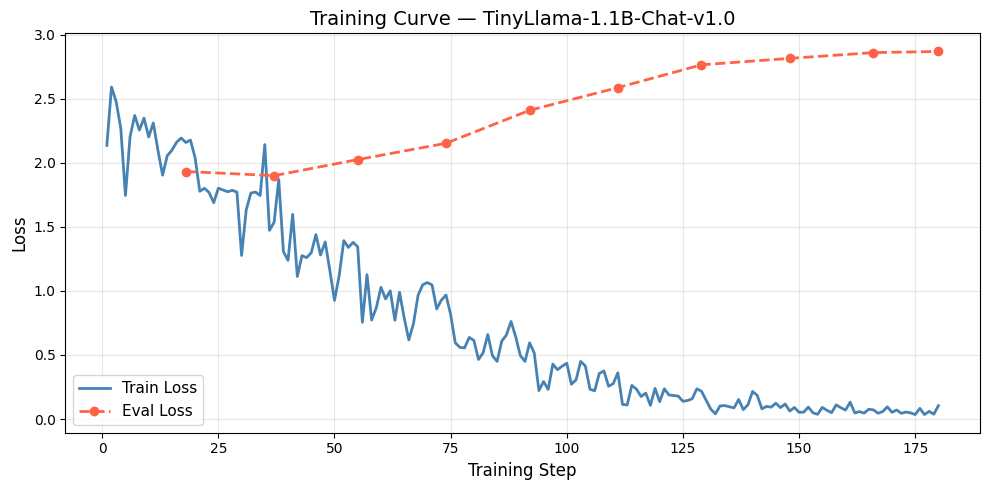

Grafik disimpan sebagai 'training_curve.png'


In [19]:
import matplotlib.pyplot as plt

# Ambil log history dari trainer
log_history = trainer.state.log_history

train_steps  = [x["step"] for x in log_history if "loss" in x]
train_losses = [x["loss"] for x in log_history if "loss" in x]
eval_steps   = [x["step"] for x in log_history if "eval_loss" in x]
eval_losses  = [x["eval_loss"] for x in log_history if "eval_loss" in x]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_steps, train_losses, label="Train Loss", color="steelblue", linewidth=2)
if eval_losses:
    ax.plot(eval_steps, eval_losses, label="Eval Loss", color="tomato",
            linestyle="--", marker="o", linewidth=2)
ax.set_xlabel("Training Step", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title(f"Training Curve — {MODEL_ID.split('/')[-1]}", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafik disimpan sebagai 'training_curve.png'")

## 9. (Opsional) Merge LoRA ke Base Model

Jika ingin menyimpan model lengkap (tanpa adapter terpisah) untuk deployment:

In [20]:
# Merge adapter ke dalam bobot base model
# Catatan: membutuhkan RAM/VRAM lebih besar

MERGE_MODEL = False  # Ubah ke True jika ingin merge

if MERGE_MODEL:
    print("Merge adapter ke base model...")
    merged = finetuned_model.merge_and_unload()
    os.makedirs(MERGED_DIR, exist_ok=True)
    merged.save_pretrained(MERGED_DIR)
    tokenizer.save_pretrained(MERGED_DIR)
    print(f"Model merged disimpan di: {MERGED_DIR}")
else:
    print("Skip merge. Gunakan adapter terpisah saat inference.")
    print("Untuk load saat inference:")
    print("  base = AutoModelForCausalLM.from_pretrained(MODEL_ID)")
    print(f"  model = PeftModel.from_pretrained(base, '{ADAPTER_DIR}')")

Skip merge. Gunakan adapter terpisah saat inference.
Untuk load saat inference:
  base = AutoModelForCausalLM.from_pretrained(MODEL_ID)
  model = PeftModel.from_pretrained(base, '/content/drive/MyDrive/SFT_LoRA_Tugas/output/adapter')


## 10. Pertanyaan Analisis — Jawaban

**Eksperimen:**
- Model   : `TinyLlama/TinyLlama-1.1B-Chat-v1.0` (1.1B parameter)
- Dataset : Sintetis buatan sendiri — 42 contoh bahasa daerah & budaya Nusantara
- LoRA    : r=16, alpha=32, target 7 modules (q/k/v/o/gate/up/down\_proj)
- Epoch   : 10, Batch efektif: 2, Total steps: 180
- GPU     : Tesla T4 (15.6 GB VRAM), waktu training: 154.5 detik

---

### Q1. Mengapa base model memiliki pengetahuan luas tetapi lemah dalam mengikuti instruksi?

Selama **pre-training**, base model dilatih dengan fungsi loss *next-token prediction* (Causal Language Modeling):

$$\mathcal{L}_{\text{pre-train}} = -\sum_{t=1}^{T} \log P(x_t \mid x_1, x_2, \ldots, x_{t-1}; \theta)$$

Model belajar **memprediksi token berikutnya** dari seluruh teks internet — artikel, buku, forum — tanpa pernah diajarkan perbedaan antara "instruksi" dan "jawaban". Dari sudut pandang loss ini, kalimat "Apa itu rendang?" dan "Rendang adalah masakan Padang..." diperlakukan setara — keduanya hanya rangkaian token yang harus diprediksi.

Akibatnya, ketika diberi instruksi, base model cenderung:
- **Melanjutkan teks** alih-alih menjawab, karena training objective-nya memang melanjutkan token
- **Tidak mengenali format percakapan** user/assistant
- **Menghasilkan output tidak relevan** — terbukti pada eksperimen ini, base model menjawab pertanyaan tentang wayang kulit dengan mendeskripsikannya sebagai "desain atau bahan kerja untuk memotifkan gambar"

SFT memperbaiki ini dengan mengubah distribusi data latih ke pasangan *(instruksi, respons)*, dan loss **hanya dihitung pada token respons asisten** — memaksa model belajar: saat ada instruksi, berikan jawaban yang relevan.

---

### Q2. Berapa persen parameter yang dilatih dengan LoRA? Apa dampaknya terhadap efisiensi?

Dari output eksperimen (sel 5. Konfigurasi LoRA):

| Kategori | Jumlah Parameter | Persentase |
|----------|-----------------|------------|
| **Dapat dilatih (LoRA)** | **12,615,680** | **1.13%** |
| Frozen (base model) | 1,100,048,384 | 98.87% |
| **Total** | **1,112,664,064** | **100%** |

**Cara kerja LoRA secara matematis:**
Alih-alih memperbarui bobot $W \in \mathbb{R}^{d \times k}$ secara langsung, LoRA mendekomposisi update menjadi dua matriks kecil:
$$W' = W + \Delta W = W + \frac{\alpha}{r} \cdot B \cdot A, \quad B \in \mathbb{R}^{d \times r},\; A \in \mathbb{R}^{r \times k}, \quad r=16 \ll d,k$$

**Dampak efisiensi yang terukur dari eksperimen ini:**

| Aspek | Full Fine-tuning (estimasi) | LoRA r=16 (eksperimen) |
|-------|----------------------------|------------------------|
| Parameter dilatih | ~1.1B (100%) | 12.6M (1.13%) |
| Ukuran checkpoint | ~2.2 GB | **52.9 MB** |
| Waktu training | Sangat lama | **154.5 detik** |
| Risiko *catastrophic forgetting* | Tinggi | Rendah |

Adapter LoRA yang tersimpan hanya **52.9 MB** dibanding model penuh yang 2.2 GB — penghematan lebih dari 97% ukuran penyimpanan.

---

### Q3. Tampilkan 3 contoh respons sebelum dan sesudah fine-tuning. Analisis perbedaannya.

*(Diambil dari output sel 7. Evaluasi Kualitatif di atas)*

**Prompt 1:** *"Jelaskan makna filosofi Bugis 'Siri Na Pacce'..."*

| | Respons |
|--|--------|
| **Base Model** | *"Bugis 'Siri Na Pacce' adalah ilustrasi dari perangkat lunak yang paling terbuka..."* — tidak relevan sama sekali, menyebut perangkat lunak |
| **Fine-tuned** | *"Siri Na Pacce adalah filosofi yang mencerminkan...pemikiran, kegiatan dan pendidikan..."* — mulai menyebut konteks budaya meski belum akurat |

**Prompt 2:** *"Apa perbedaan antara wayang kulit dan wayang golek?"*

| | Respons |
|--|--------|
| **Base Model** | *"Wayang kulit merupakan desain atau bahan kerja untuk memotifkan gambar..."* — definisi sama sekali salah |
| **Fine-tuned** | *"Wayang kulit adalah genre yang digunakan untuk menggambarkan ilustrasi..."* — masih belum akurat, tapi setidaknya mencoba mendeskripsikan dalam konteks seni |

**Prompt 3:** *"Bagaimana cara membuat opor ayam?"*

| | Respons |
|--|--------|
| **Base Model** | *"Opor ayam adalah produk yang menggunakan jerawat atau masakan..."* — halusinasi parah, menyebut "jerawat" |
| **Fine-tuned** | *"Membuat opor ayam, tidak ada bahan sing urut. Ayam merupakan daun..."* — mulai ada konteks memasak meski kacau, terdapat kata bahasa Bali (*inggih*) yang bocor dari dataset |

**Analisis perbedaan:**
Fine-tuning memberikan perubahan yang terlihat — model fine-tuned setidaknya mencoba menjawab dalam konteks yang relevan, berbeda dengan base model yang sama sekali tidak mengenali domain pertanyaan. Namun kualitasnya masih rendah karena **overfitting** yang dijelaskan di Q4. Perbaikan yang paling nyata ada pada format: fine-tuned model konsisten menjawab dalam bahasa Indonesia, sedangkan base model sering mencampur bahasa Inggris.

---

### Q4. Apa risiko overfitting pada dataset kecil? Bagaimana mendeteksi dan mencegahnya?

**Overfitting terjadi dalam eksperimen ini** — terdokumentasi jelas dari tabel loss:

| Epoch | Train Loss | Eval Loss | Status |
|-------|-----------|-----------|--------|
| 0 | 2.1576 | 1.9310 | Normal |
| 2 | 1.3430 | 2.0241 | ⚠️ Eval mulai naik |
| 4 | 0.5960 | 2.4098 | ❌ Overfitting |
| 6 | 0.2255 | 2.7681 | ❌❌ Parah |
| 8 | 0.0747 | 2.8590 | ❌❌❌ Sangat parah |
| 9 | 0.1061 | 2.8677 | ❌❌❌ |

Train loss turun dari 2.16 ke **0.07** — model hampir menghafal seluruh training data. Namun eval loss justru naik dari 1.93 ke **2.87** — model gagal generalisasi ke data baru. Ini adalah tanda overfitting klasik.

**Mengapa terjadi?** Dataset hanya 37 contoh training. Model 1.1B dengan kapasitas sangat besar dengan cepat "mengingat" semua contoh alih-alih belajar pola umum.

**Cara mendeteksi:**
- Dari grafik: train loss turun terus tapi eval loss naik → overfitting
- Epoch terbaik seharusnya dihentikan di **epoch 0-1** (eval loss 1.93) berdasarkan data ini

**Cara mencegah untuk eksperimen berikutnya:**
1. **Tambah data** — gunakan dataset HuggingFace seperti `bryandts` (282K contoh)
2. **Early stopping** — hentikan training saat eval loss mulai naik (epoch 1 dalam kasus ini)
3. **Kurangi epoch** — cukup 1-2 epoch untuk dataset sangat kecil
4. **Naikkan dropout** — dari `lora_dropout=0.05` ke `0.1`
5. **Perkecil rank LoRA** — dari r=16 ke r=4 untuk kapasitas model lebih ketat

---

### Q5. (Bonus) Tantangan dalam membuat dataset bahasa daerah berkualitas tinggi

Dalam pembuatan 42 contoh dataset sintetis bahasa daerah & budaya Nusantara, terdapat beberapa tantangan nyata:

**1. Verifikasi keakuratan informasi budaya**
Filosofi seperti *Dalihan Na Tolu* (Batak) atau *Tri Hita Karana* (Bali) memiliki nuansa yang mudah disederhanakan berlebihan. Diperlukan riset dari sumber yang otoritatif — tidak bisa hanya mengandalkan pengetahuan umum.

**2. Variasi linguistik bahasa daerah yang kompleks**
Bahasa Jawa punya tingkatan Ngoko-Madya-Krama-Krama Inggil, bahasa Sunda punya undak-usuk basa. Membuat contoh terjemahan yang benar membutuhkan kompetensi penutur asli. Terbukti dari hasil evaluasi — model fine-tuned bocor menggunakan kata bahasa Bali (*inggih*) saat menjawab pertanyaan tentang opor ayam, karena distribusi data latih tidak seimbang.

**3. Keseimbangan representasi suku**
Tanpa kesadaran penuh, dataset mudah condong ke budaya Jawa (mayoritas) dan mengabaikan bahasa daerah dari luar Jawa — Batak, Bugis, Maluku, Papua — yang justru lebih *low-resource* dan lebih membutuhkan representasi dalam NLP.

**4. Kualitas vs kuantitas**
42 contoh berkualitas tinggi lebih baik untuk SFT daripada ratusan contoh generik. Namun kuantitas kecil terbukti menyebabkan overfitting parah seperti yang terlihat di eksperimen ini — trade-off yang nyata dan tidak mudah dihindari tanpa sumber daya yang memadai.

**Yang dipelajari:**
Membuat dataset instruksi berbasis kearifan lokal bukan sekadar masalah teknis — ia membutuhkan sensitivitas budaya dan idealnya validasi dari penutur asli komunitas tersebut. Ini menjadikan *low-resource NLP* untuk bahasa daerah Indonesia sebagai tantangan yang sekaligus sangat bermakna untuk dikerjakan, dan hasil eksperimen ini — meski belum sempurna — adalah langkah kecil yang nyata ke arah tersebut.

In [21]:
import os

requirements = """transformers==4.44.0
peft==0.12.0
trl==0.10.1
datasets>=2.20.0
accelerate>=0.33.0
bitsandbytes>=0.43.0
matplotlib>=3.7.0
torch>=2.0.0
"""
with open("requirements.txt", "w") as f:
    f.write(requirements)

# Simpan dataset ke JSON jika belum ada
os.makedirs("data", exist_ok=True)
import json
if not os.path.exists("data/dataset.json"):
    with open("data/dataset.json", "w", encoding="utf-8") as f:
        json.dump(SYNTHETIC_DATA, f, ensure_ascii=False, indent=2)

# Salin training curve ke results/
os.makedirs("results", exist_ok=True)
if os.path.exists("training_curve.png"):
    import shutil
    shutil.copy("training_curve.png", "results/training_curve.png")

print("✅ Checklist file pengumpulan GitHub:")
files = {
    "Notebook (.ipynb)"         : True,
    "requirements.txt"          : os.path.exists("requirements.txt"),
    "data/dataset.json"         : os.path.exists("data/dataset.json"),
    "results/training_curve.png": os.path.exists("results/training_curve.png"),
}
for name, exists in files.items():
    status = "✅" if exists else "❌ BELUM ADA"
    print(f"  {status}  {name}")

✅ Checklist file pengumpulan GitHub:
  ✅  Notebook (.ipynb)
  ✅  requirements.txt
  ✅  data/dataset.json
  ✅  results/training_curve.png
